In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.read_csv ('canais_venda.csv', sep=';')
pd.read_csv ('clientes.concat.csv', sep=';')
pd.read_csv ('funcionarios.concat.csv', sep=';')
pd.read_csv ('reservas.concat.corrigido.csv', sep=';')
pd.read_csv ('tipos_quarto.concat.csv', sep=';')
pd.read_csv ('unidades.concat.csv', sep=';')

,id_unidade,nome_unidade,cidade,regiao,categoria_hotel(estrelas),num_quartos_total
0,1,NaraHoteis Ipanema,Rio de Janeiro,Capital,5,80
1,2,NaraHoteis Barra da Tijuca,Rio de Janeiro,Capital,4,120
2,3,NaraHoteis Centro,Rio de Janeiro,Capital,3,60
3,4,NaraHoteis Santa Teresa,Rio de Janeiro,Capital,4,45
4,5,NaraHoteis Nova Iguaçu Centro,Nova Iguaçu,Baixada Fluminense,3,50
5,6,NaraHoteis Nova Iguaçu Park,Nova Iguaçu,Baixada Fluminense,3,55
6,7,NaraHoteis Petrópolis,Petrópolis,Serra,5,70
7,8,NaraHoteis Teresópolis,Teresópolis,Serra,4,60
8,9,NaraHoteis Friburgo,Nova Friburgo,Serra,4,55
9,10,NaraHoteis Paraty,Paraty,Costa Verde,5,75


In [3]:
import pandas as pd

# 1. Carregando as bases com os nomes atualizados
df_reservas = pd.read_csv('reservas.concat.corrigido.csv', sep=';')
df_tipos_quarto = pd.read_csv('tipos_quarto.concat.csv', sep=';')
df_unidades = pd.read_csv('unidades.concat.csv', sep=';')

# Bases extras carregadas para as próximas etapas do painel
df_canais_venda = pd.read_csv('canais_venda.csv', sep=';')
df_clientes = pd.read_csv('clientes.concat.csv', sep=';')
df_funcionarios = pd.read_csv('funcionarios.concat.csv', sep=';')

# 2. Executando o cruzamento da Pergunta 3
df_merged = df_reservas.merge(df_tipos_quarto[['id_tipo_quarto', 'valor_diaria_base']], on='id_tipo_quarto', how='left')
df_merged = df_merged.merge(df_unidades[['id_unidade', 'nome_unidade', 'regiao']], on='id_unidade', how='left')
df_merged['faturamento_reserva'] = df_merged['qtd_diarias'] * df_merged['valor_diaria_base']

print("Bases carregadas e cruzamento realizado com sucesso!")

Bases carregadas e cruzamento realizado com sucesso!


--- Evolução da Rede ---


,ano,qtd_reservas,faturamento_total
0,2023,1234,2567400.0
1,2024,1223,2640690.0
2,2025,1356,2814230.0
3,2026,836,1765860.0



--- Evolução das Unidades Problemáticas ---


nome_unidade,NaraHoteis Centro,NaraHoteis Nova Iguaçu Centro,NaraHoteis Copacabana Premium
ano,,,
2023,91750.0,83110.0,0.0
2024,103390.0,85870.0,0.0
2025,238760.0,138500.0,163130.0
2026,54340.0,108560.0,135370.0


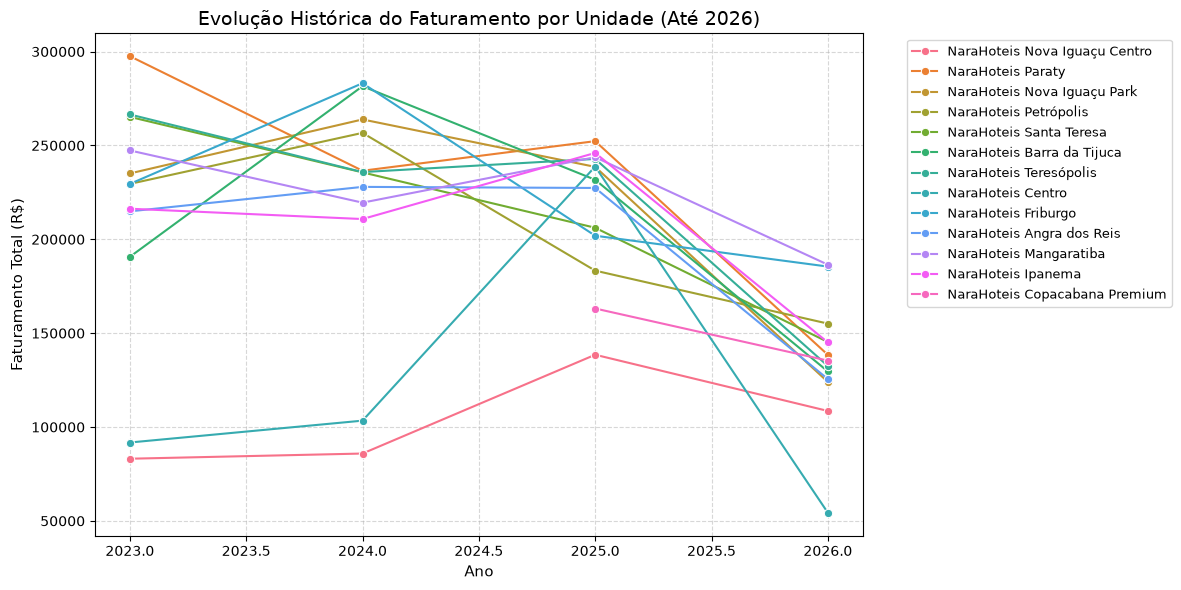

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convertendo a coluna de data para o formato correto de tempo
# Ajuste 'data_checkin' para o nome exato da coluna de data no seu DataFrame
df_merged['data_checkin'] = pd.to_datetime(df_merged['data_checkin'])
df_merged['ano'] = df_merged['data_checkin'].dt.year

# 2. Visão 1: A rede como um todo está crescendo ou caindo?
evolucao_rede = df_merged.groupby('ano').agg(
    qtd_reservas=('id_reserva', 'count'),
    faturamento_total=('faturamento_reserva', 'sum')
).reset_index()
print("--- Evolução da Rede ---")
display(evolucao_rede)

# 3. Visão 2: Como estão as unidades problemáticas ao longo dos anos?
evolucao_unidades = df_merged.groupby(['ano', 'nome_unidade'])['faturamento_reserva'].sum().unstack().fillna(0)
print("\n--- Evolução das Unidades Problemáticas ---")
display(evolucao_unidades[['NaraHoteis Centro', 'NaraHoteis Nova Iguaçu Centro', 'NaraHoteis Copacabana Premium']])

# 4. Gráfico Visual
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_merged, x='ano', y='faturamento_reserva', hue='nome_unidade', estimator='sum', errorbar=None, marker='o')
plt.title('Evolução Histórica do Faturamento por Unidade (Até 2026)', fontsize=14)
plt.ylabel('Faturamento Total (R$)', fontsize=11)
plt.xlabel('Ano', fontsize=11)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

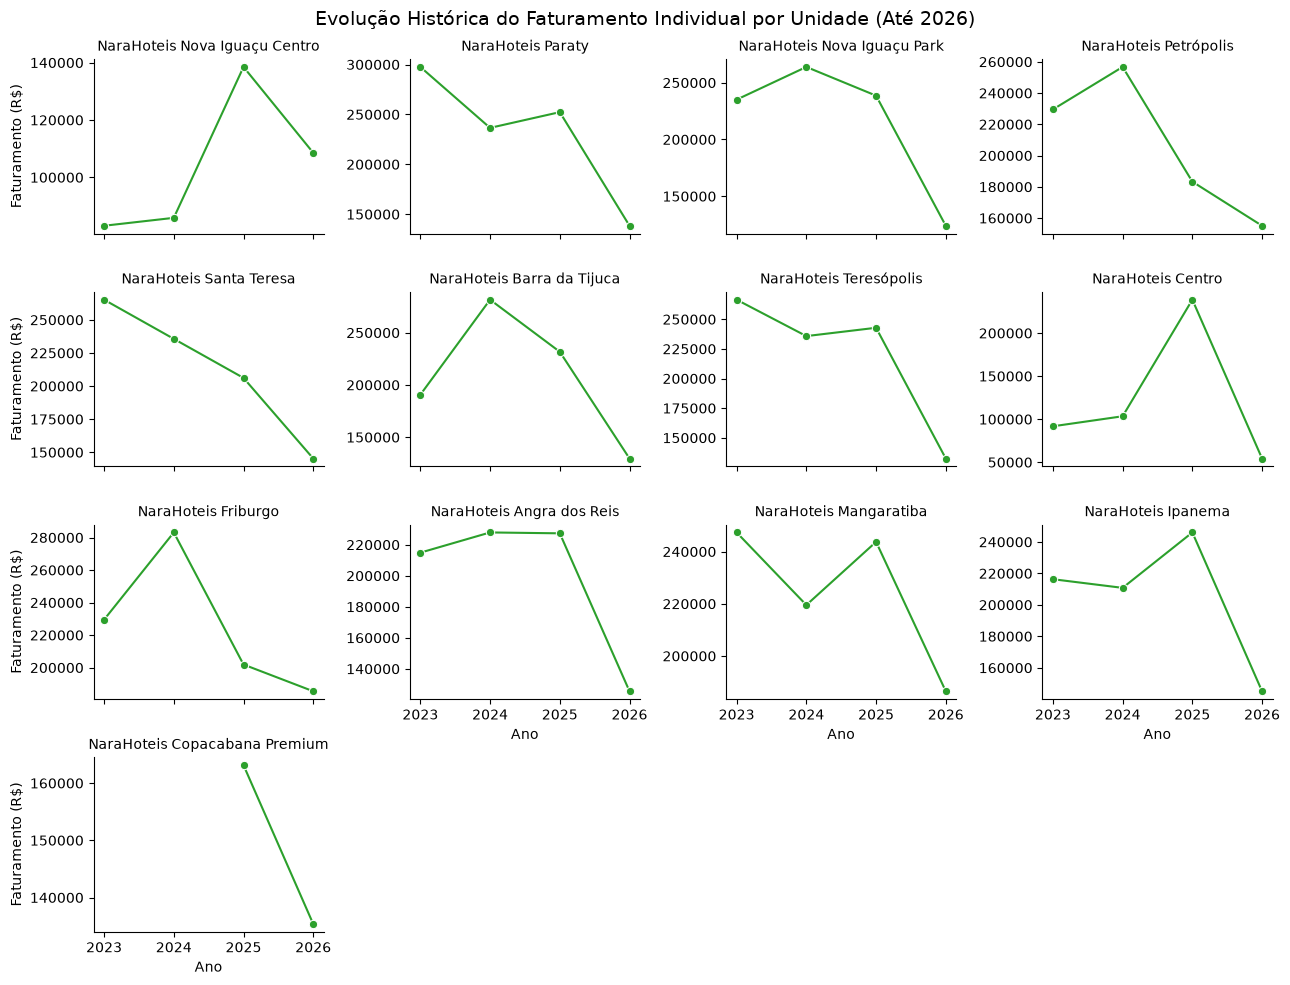

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Garantindo que a coluna 'ano' e 'faturamento_reserva' estão prontas
df_merged['data_checkin'] = pd.to_datetime(df_merged['data_checkin'])
df_merged['ano'] = df_merged['data_checkin'].dt.year

# Criando uma grade de gráficos (FacetGrid) - 3 colunas por 4 linhas (12 unidades)
g = sns.FacetGrid(df_merged, col="nome_unidade", col_wrap=4, height=2.5, aspect=1.3, sharey=False)

# Mapeando o gráfico de linhas para cada quadrante
g.map_dataframe(sns.lineplot, x="ano", y="faturamento_reserva", estimator="sum", marker="o", color="#2ca02c", errorbar=None)

# Ajustando os títulos e eixos de cada minigráfico
g.set_axis_labels("Ano", "Faturamento (R$)")
g.set_titles(col_template="{col_name}", size=10)

# Melhorando o espaçamento
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Evolução Histórica do Faturamento Individual por Unidade (Até 2026)', fontsize=14)

plt.tight_layout()
plt.show()

PERGUNTA 9

Com a base agora cobrindo até 2026, quero entender a evolução da rede ao longo do tempo: a situação das unidades já apontadas como problemáticas mudou nesse período? A rede como um todo está crescendo, estável ou em queda?

RESPOSTA 9

A Evolução Global da Rede (Crescimento Consistente)
Tendência de Alta (2023–2025): A rede apresentou um crescimento sólido e sustentável nos primeiros três anos analisados. O volume de reservas subiu de 1.234 (2023) para 1.356 (2025), e a faturação total acompanhou essa subida, saltando de R$ 2,56 milhões para R$ 2,81 milhões.

O Efeito do Ano Corrente (2026): Os números de 2026 (836 reservas e R$ 1,76 milhões) refletem um período parcial (dados contabilizados até setembro). Esta redução não representa uma quebra estrutural do negócio, mas sim um retrato incompleto do ano em curso.

A rede NaraHoteis demonstrou uma trajetória de crescimento saudável e contínua entre 2023 e 2025. As unidades historicamente tidas como problemáticas (Centro e Nova Iguaçu Centro) conseguiram contrariar o pessimismo inicial, duplicando o seu volume de faturação no período. A introdução bem-sucedida de Copacabana Premium em 2025 reforça a expansão do portefólio para o segmento de luxo, restando agora à gestão comercial otimizar a taxa de ocupação destas novas apostas para acompanhar o ritmo de crescimento da rede.